In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Activate if rendering figure
import pylustrator

pylustrator.start()

# allow cross-cell figure collection
from matplotlib import _pylab_helpers

_pylab_helpers.Gcf.destroy_all = lambda *args: ...

QApplication: invalid style override 'adwaita' passed, ignoring it.
	Available styles: Windows, Fusion


In [34]:
# Preamble
from matplotlib import pyplot as plt
import scienceplots
from machinable import get
import numpy as np
import pandas as pd
from tabulate import tabulate
from uncertainties import ufloat
from common import *

plt.rcParams.update({"figure.dpi": "300"})

np.set_printoptions(linewidth=np.inf, suppress=True)

get(
    "machinable.index",
    "./index",
).__enter__()

plt.style.use(["science", "nature"])

cc = {
    "blue": "#0C5DA5",
    "green": "#00B945",
    "yellow": "#FF9500",
    "red": "#FF2C00",
    "violet": "#845B97",
    "black": "#474747",
    "grey": "#9e9e9e",
}

In [ ]:
figure = plt.figure(1)

# All cells baseline

In [5]:
_ca1_samplers = get("interface._ca1_samplers")

globus_download(_ca1_samplers)

In [6]:
initial_hvs = {}

for p in _ca1_samplers.populations():
    experiments = _ca1_samplers.components.filter(lambda x: p in x.label())
    num_initial = experiments[0].num_initial_samples
    nadir = fronts_nadir(experiments)

    for experiment in experiments:
        sampler_name = experiment.config.dopt_params.initial_method

        initial_hvs.setdefault(p, {})
        initial_hvs[p].setdefault(sampler_name, [])
        initial_hvs[p].setdefault(sampler_name + "_initial", [])

        hv = experiment.norm_hv(nadir)
        initial_hvs[p][sampler_name].append(hv)

        hv = experiment.norm_hv_region(nadir, region=[0, num_initial])
        initial_hvs[p][sampler_name + "_initial"].append(hv)

In [7]:
stash("single-cells-initial-hvs", initial_hvs)

In [2]:
initial_hvs = restore("single-cells-initial-hvs")

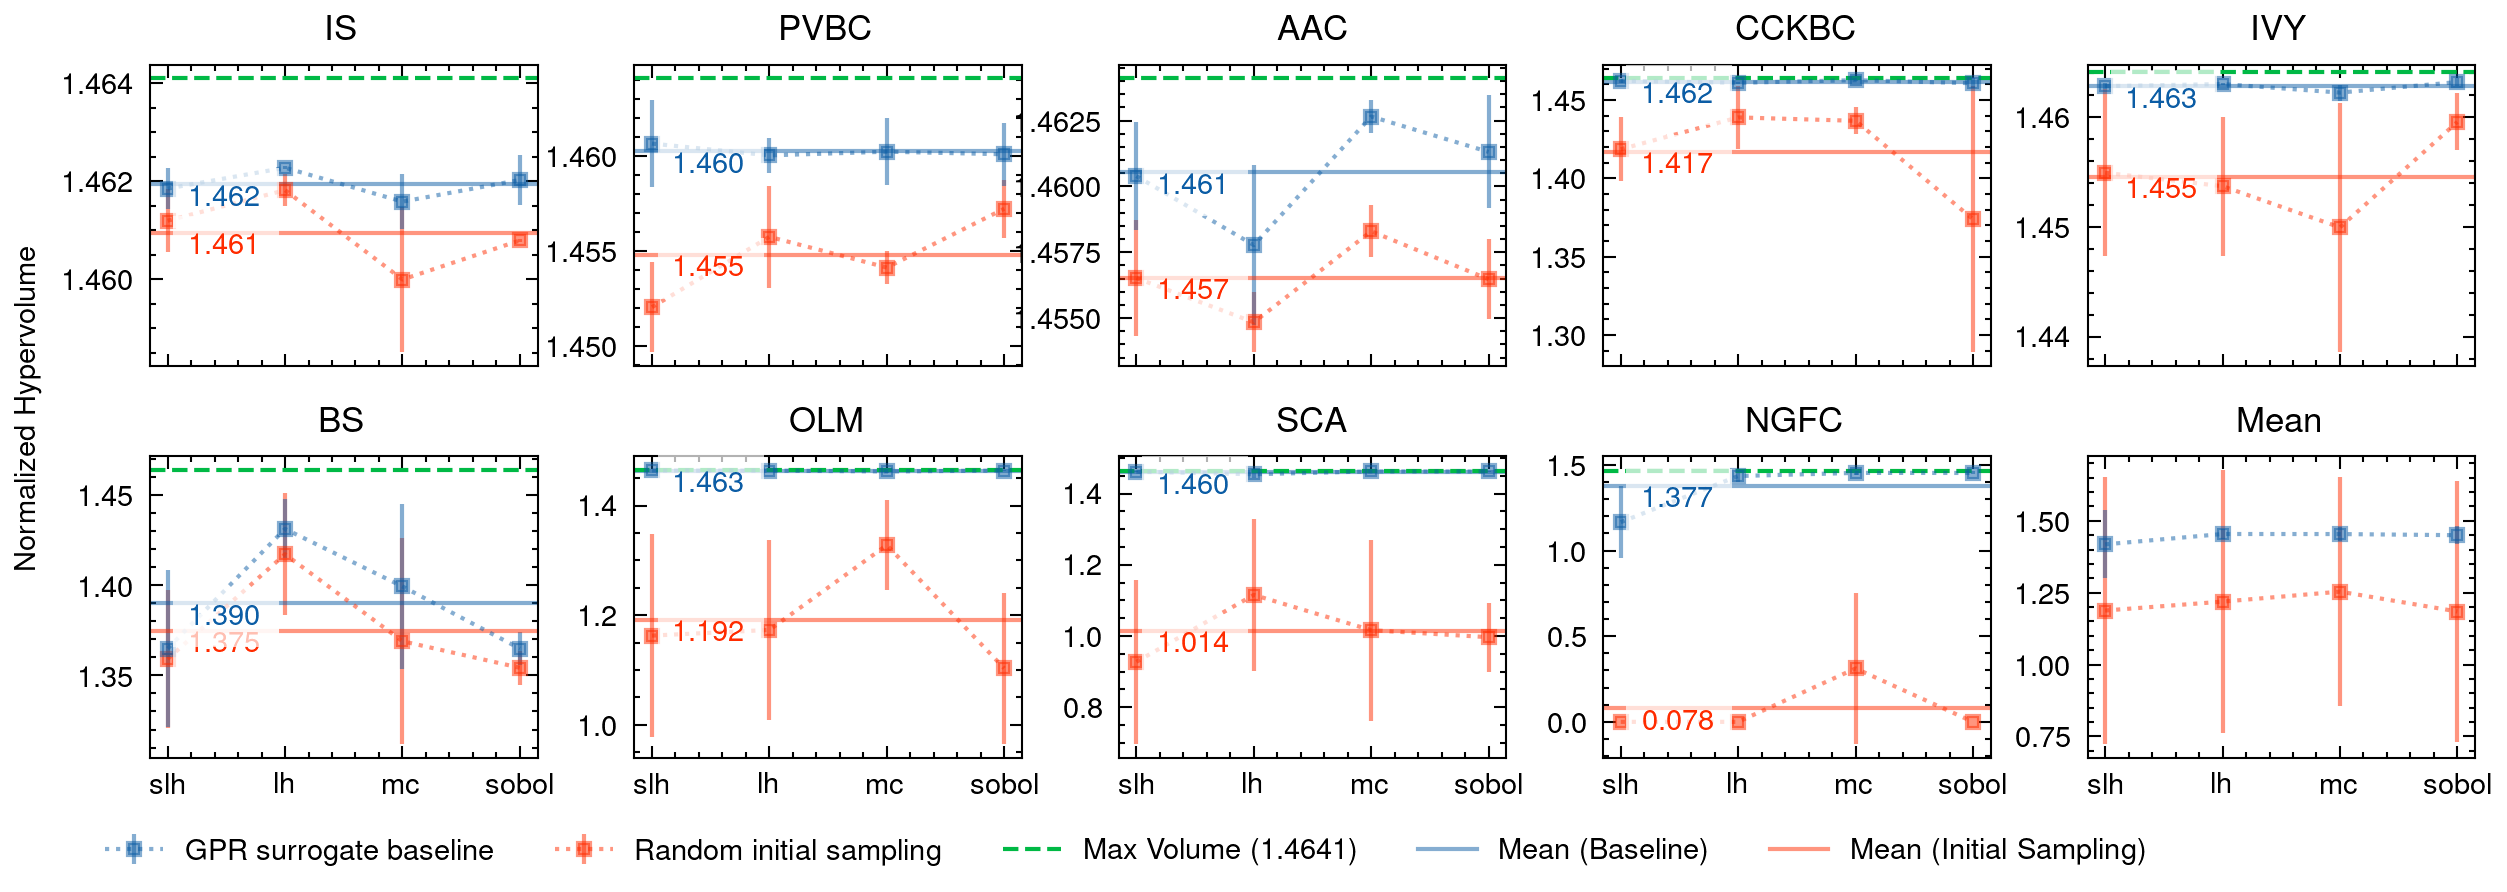

In [38]:
fig, axs = plt.subplots(2, 5, figsize=(10, 3), sharey=False, sharex=True)

c = {0: cc["red"], 1: cc["blue"]}

for ix, (ax, cell_type) in enumerate(
    zip(
        axs.flatten()[:-1],
        ["IS", "PVBC", "AAC", "CCKBC", "IVY", "BS", "OLM", "SCA", "NGFC"],
    )
):
    means_initial = []
    stds_initial = []
    means = []
    stds = []
    labels = []
    for sampler_name, hvs in initial_hvs[cell_type].items():
        if sampler_name.endswith("_initial"):
            means_initial.append(np.mean(hvs))
            stds_initial.append(np.std(hvs))
        else:
            means.append(np.mean(hvs))
            stds.append(np.std(hvs))
            labels.append(sampler_name)

    ax.errorbar(
        labels,
        means_initial,
        yerr=stds_initial,
        color=c[0],
        fmt="s:",
        alpha=0.5,
        label="Random initial sampling",
    )
    ax.errorbar(
        labels,
        means,
        yerr=stds,
        color=c[1],
        fmt="s:",
        alpha=0.5,
        label="GPR surrogate baseline",
    )

    for i, ms in enumerate([means_initial, means]):
        mean_value = np.mean(ms)
        ax.axhline(
            y=mean_value,
            color=c[i],
            linestyle="-",
            alpha=0.5,
            label="Mean (Initial Sampling)" if i == 0 else "Mean (Baseline)",
        )
        ax.text(
            len(labels) - 3.5,
            mean_value,
            f"{mean_value:.3f}",
            color=c[i],
            verticalalignment="top",
            horizontalalignment="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    ax.axhline(
        y=1.1**4, color=cc["green"], linestyle="--", label=f"Max Volume ({1.1**4:.4f})"
    )
    # if ix < 3:
    #     ax.set_ylim(1.4, 1.1**4 * 1.05)
    # ax.legend()
    ax.set_title(cell_type)  # , y=0.7)

    # ax.set_xticklabels(labels, rotation=45, ha='right')

ax2 = axs[1][-1]
for i, ms in enumerate([means_initial, means]):
    mean_by_sampler = {
        sampler: np.mean(
            [
                models[(sampler + "_initial") if i == 0 else sampler]
                for models in initial_hvs.values()
            ]
        )
        for sampler in labels
    }
    std_by_sampler = {
        sampler: np.std(
            [
                models[(sampler + "_initial") if i == 0 else sampler]
                for models in initial_hvs.values()
            ]
        )
        for sampler in labels
    }
    ax2.errorbar(
        labels,
        [mean_by_sampler[l] for l in labels],
        yerr=[std_by_sampler[l] for l in labels],
        fmt="s:",
        color=c[i],
        alpha=0.5,
        label="Mean across cells",
    )

ax2.set_title("Mean")  # , y=0.7)

# axs[0][0].set_ylabel("Normalized Hypervolume")
# axs[1][0].set_ylabel("Normalized Hypervolume")
fig.text(0.08, 0.5, "Normalized Hypervolume", va="center", rotation="vertical")

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(
    reversed(handles), reversed(labels), ncol=len(labels), bbox_to_anchor=(0.8, 0.05)
)

plt.subplots_adjust(wspace=0.25, hspace=0.3)
plt.show()

In [41]:
stash("single-cells-initial-hvs", fig)

In [42]:
summary_data = {}

for cell_type, models in initial_hvs.items():
    cell_type_key = cell_type.replace("CA1_", "")
    if cell_type_key not in summary_data:
        summary_data[cell_type_key] = {}
    for sampler_name, hvs in models.items():
        mean_hv = np.mean(hvs)
        std_hv = np.std(hvs)
        summary_data[cell_type_key][sampler_name] = ufloat(mean_hv, std_hv)

summary_df = pd.DataFrame(summary_data).T

# summary_df.loc["Optimal"] = [ufloat(round(1.1**4, 2), 0)] * len(summary_df.columns)

summary_df["Mean Across Models"] = summary_df.apply(
    lambda row: ufloat(
        np.mean([val.nominal_value for val in row]),
        np.mean([val.std_dev for val in row]),
    ),
    axis=1,
)

summary_df = summary_df.sort_values(by="Mean Across Models", ascending=True)

display(summary_df)

latex_table = tabulate(
    summary_df.map(lambda x: f"${x:.2uL}$"), headers="keys", tablefmt="latex_raw"
)

,slh,slh_initial,lh,lh_initial,mc,mc_initial,sobol,sobol_initial,Mean Across Models
NGFC,1.17+/-0.21,0.0+/-0,1.435+/-0.035,0.0+/-0,1.453+/-0.012,0.3+/-0.4,1.453+/-0.009,0.0+/-0,0.73+/-0.09
SCA,1.4616+/-0.0015,0.93+/-0.23,1.454+/-0.012,1.12+/-0.21,1.46253+/-0.00015,1.02+/-0.25,1.46220+/-0.00030,1.00+/-0.10,1.24+/-0.10
OLM,1.463933+/-0.000026,1.16+/-0.19,1.463759+/-0.000032,1.17+/-0.16,1.4621+/-0.0026,1.33+/-0.08,1.46384+/-0.00013,1.10+/-0.14,1.33+/-0.07
BS,1.36+/-0.04,1.36+/-0.04,1.431+/-0.016,1.417+/-0.034,1.40+/-0.05,1.37+/-0.06,1.365+/-0.009,1.354+/-0.009,1.383+/-0.032
CCKBC,1.4622+/-0.0014,1.419+/-0.020,1.4610+/-0.0007,1.439+/-0.020,1.4627+/-0.0004,1.437+/-0.009,1.4607+/-0.0031,1.37+/-0.08,1.439+/-0.017
PVBC,1.4607+/-0.0023,1.4521+/-0.0024,1.4600+/-0.0009,1.4558+/-0.0027,1.4602+/-0.0018,1.4541+/-0.0009,1.4601+/-0.0017,1.4572+/-0.0015,1.4575+/-0.0018
AAC,1.4604+/-0.0020,1.4565+/-0.0022,1.4578+/-0.0030,1.4548+/-0.0011,1.4627+/-0.0006,1.4583+/-0.0010,1.4613+/-0.0021,1.4565+/-0.0015,1.4585+/-0.0017
IVY,1.46282+/-0.00027,1.455+/-0.008,1.46301+/-0.00012,1.454+/-0.006,1.4622+/-0.0007,1.450+/-0.011,1.46319+/-0.00034,1.4596+/-0.0026,1.459+/-0.004
IS,1.4619+/-0.0004,1.4612+/-0.0006,1.462275+/-0.000028,1.46182+/-0.00032,1.4616+/-0.0006,1.4600+/-0.0015,1.4620+/-0.0005,1.46079+/-0.00004,1.4614+/-0.0005


In [43]:
stash("single-cells-initial-hvs.tex", latex_table)

# Hypervolume convergence

In [53]:
_ca1_sopt = get("interface._ca1_sopt")

globus_download(_ca1_sopt)

populations = _ca1_sopt.populations()

sopts = _ca1_sopt.components

In [117]:
nadirs = {}
hypervolumes = {}

for p in populations:
    experiments = sopts.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )

    nadir = nadirs[p] = fronts_nadir(experiments)

    tracking = {"interfaces": []}

    for experiment in experiments:
        label = experiment.label()
        model_name = (
            label.split("_neuron::")[-1][2:].split("/")[0].replace("joint-", "")
        )

        hypervolumes.setdefault(p, {})
        hypervolumes[p].setdefault(model_name, {})

        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        if model_name == "-":
            tracking["interfaces"].append(experiment)
        if model_name == "gpr":
            tracking["ranges"] = epoch_ranges

        for epoch, region in enumerate(epoch_ranges):
            hypervolumes[p][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            hypervolumes[p][model_name][epoch].append(hv)

    # backfill eval-normalized baseline
    hypervolumes[p]["baseline"] = {}
    for epoch, region in enumerate(tracking["ranges"]):
        hypervolumes[p]["baseline"][epoch] = [
            i.norm_hv_region(nadir, region) for i in tracking["interfaces"]
        ]

In [118]:
stash("single-cells-hypervolumes", hypervolumes)
stash("single-cells-nadirs", nadirs)

In [45]:
hypervolumes = restore("single-cells-hypervolumes")
nadirs = restore("single-cells-nadirs")

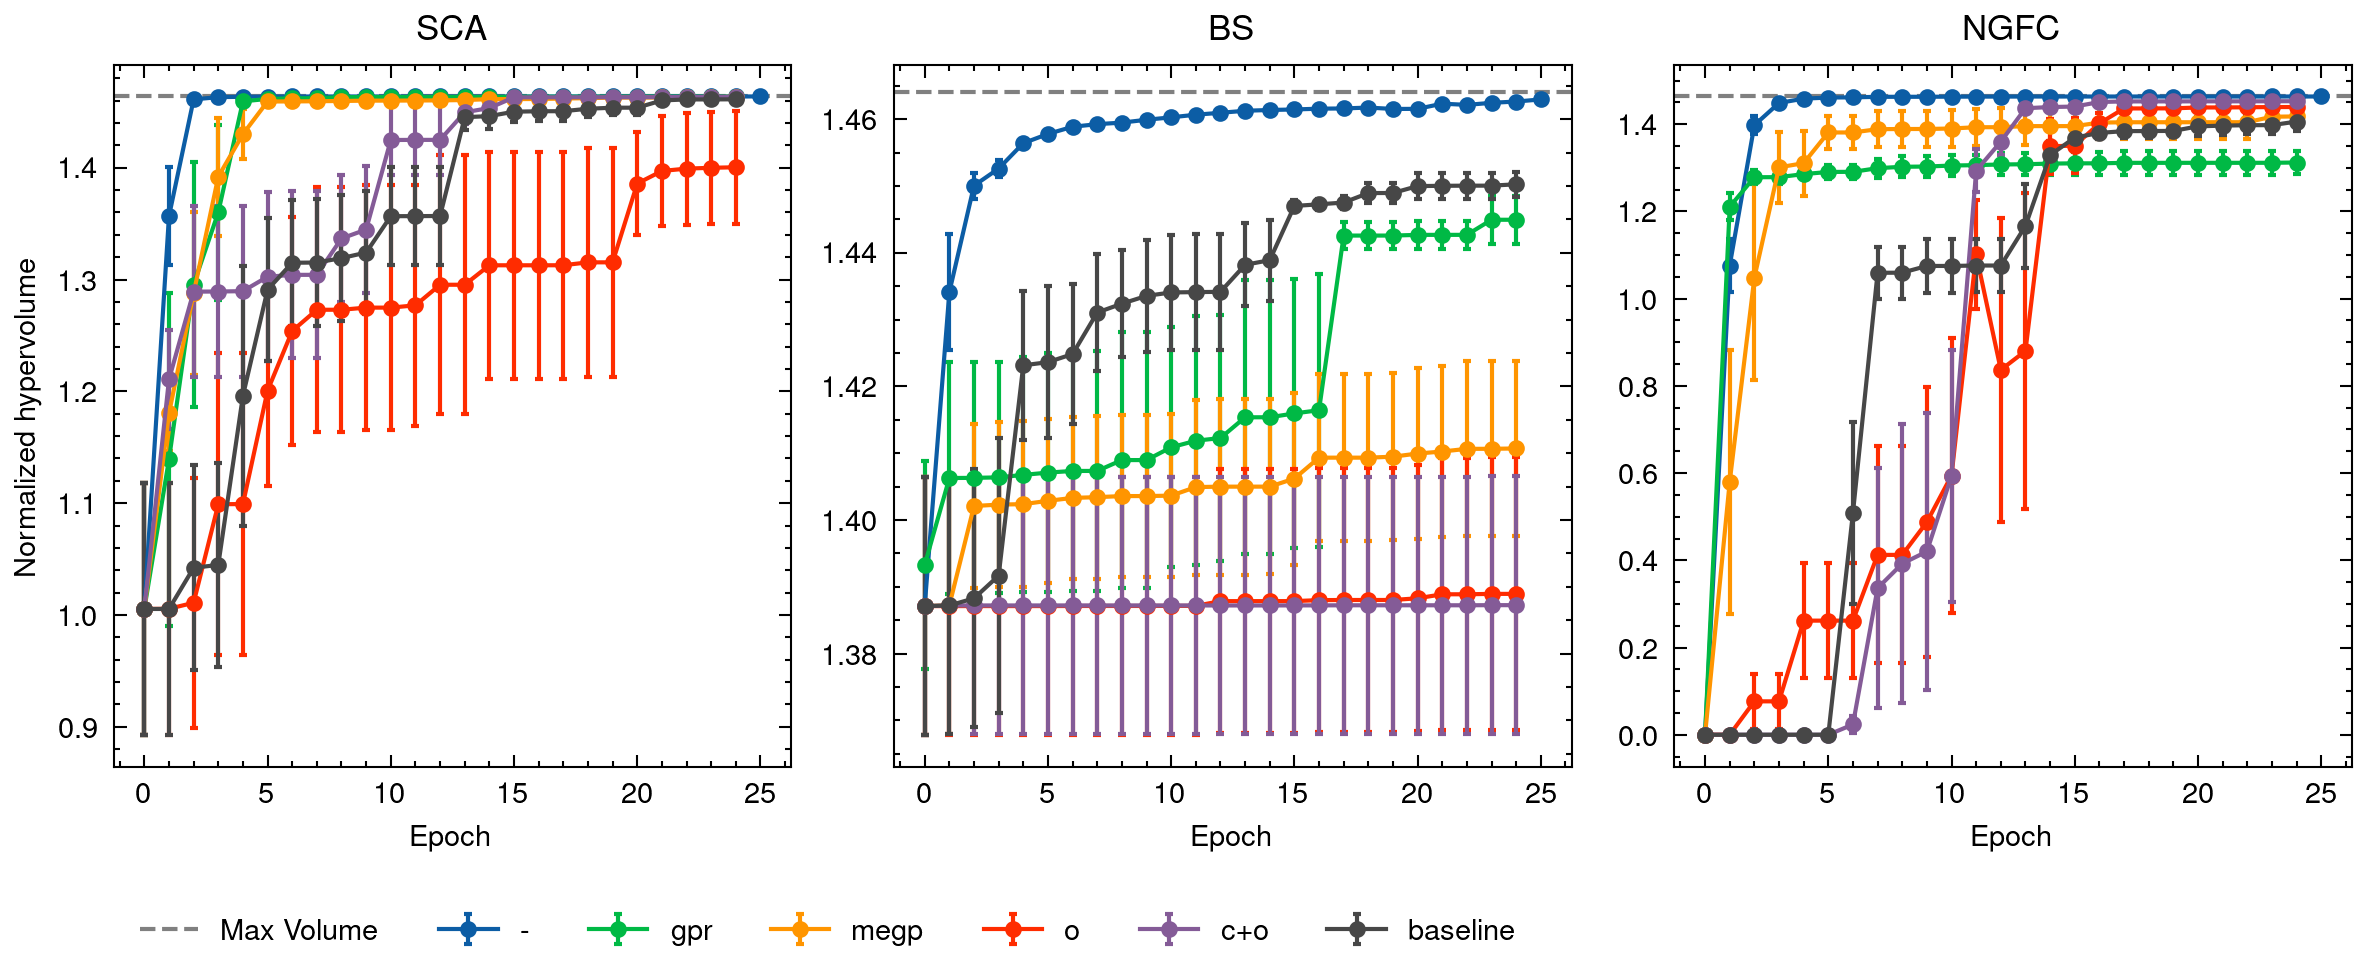

In [50]:
fig, axs = plt.subplots(1, len(hypervolumes), figsize=(8, 3), sharey=False)

for ax, (cell_type, models) in zip(axs.flatten(), hypervolumes.items()):
    for model_name, epoch_hvs in models.items():
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            # if epoch > 5 and epoch % 5 != 0:
            #     continue
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(np.std(hvs) / np.sqrt(len(hvs)))

        ax.errorbar(x, y, yerr=y_err, label=model_name, fmt="-o", capsize=1)

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel("Epoch")
    ax.axhline(y=1.1**4, color="grey", linestyle="--", label="Max Volume")
    # ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(cell_type)

axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

# stash("single-cells-hypervolumes", fig)

### Individual trials (appendix)

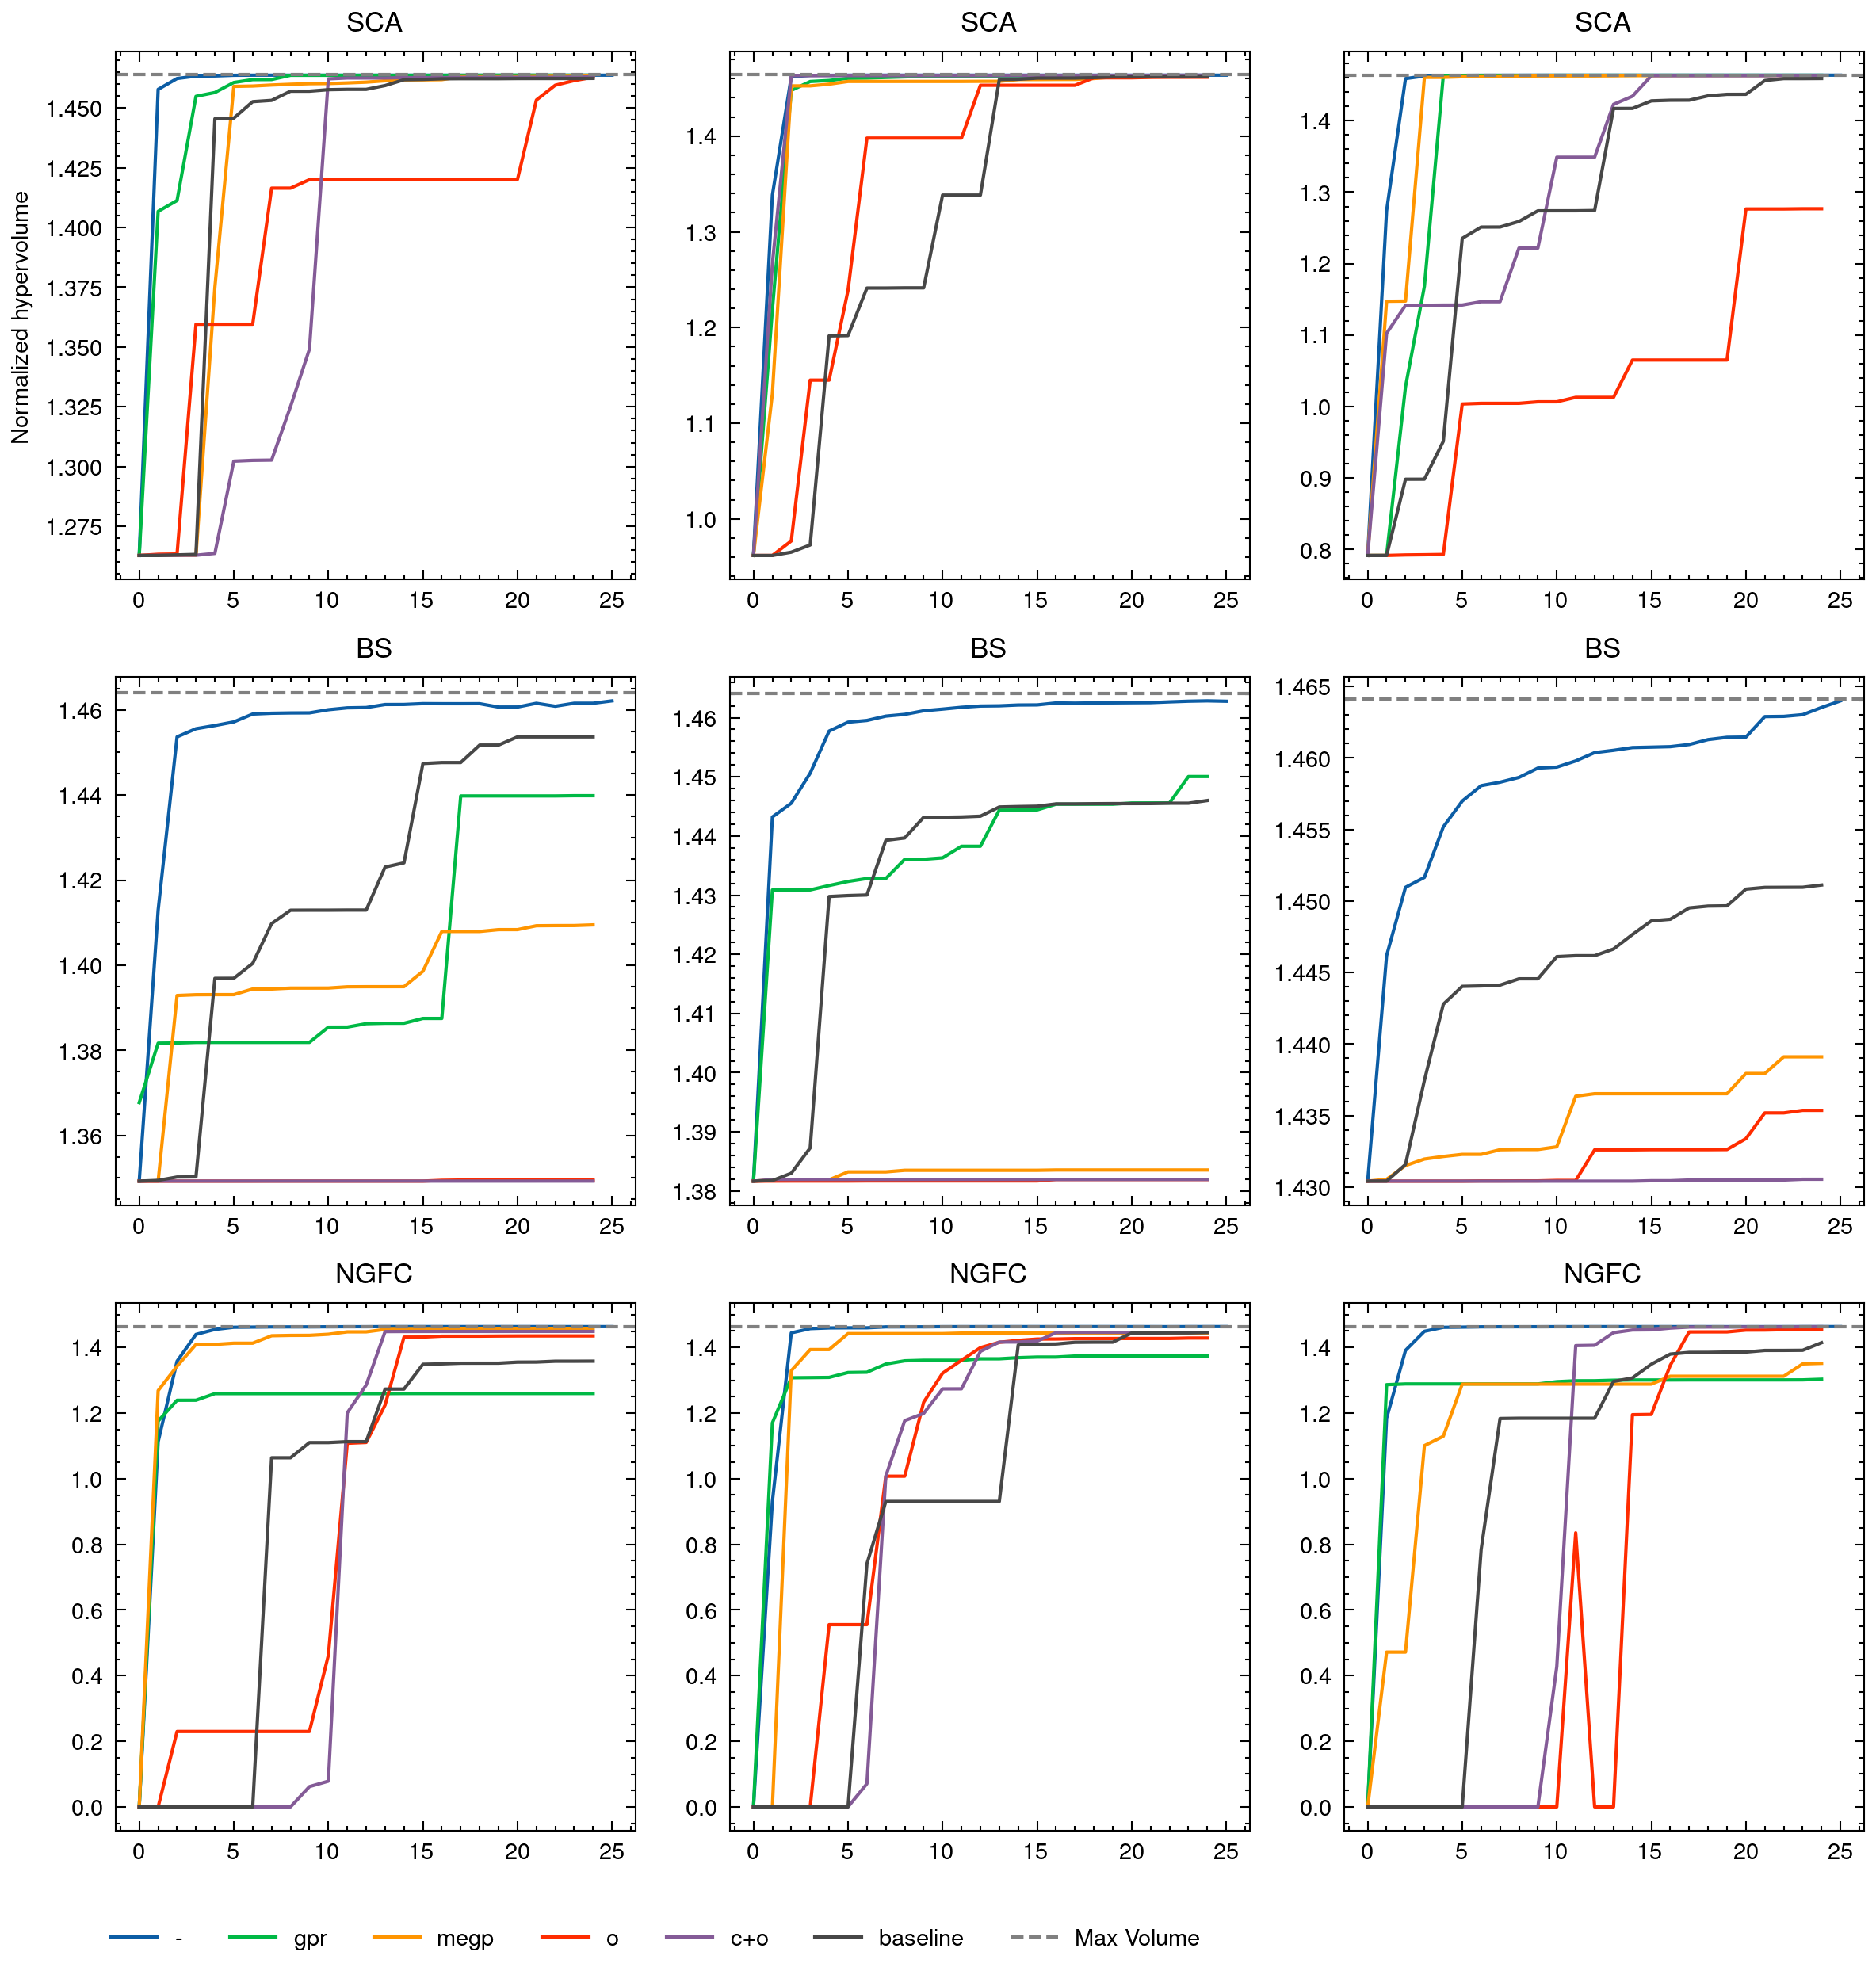

In [51]:
fig, axs = plt.subplots(3, len(hypervolumes), figsize=(8, 8), sharey=False)

for axt, (cell_type, models) in zip(axs, hypervolumes.items()):
    for trial, ax in enumerate(axt):
        for sampler_name, epoch_hvs in models.items():
            x = []
            y = []
            for epoch, hvs in epoch_hvs.items():
                x.append(int(epoch))
                if trial >= len(hvs):
                    y.append(np.nan)
                    continue
                y.append(hvs[trial])

            ax.plot(x, y, label=sampler_name)

        # ax.set_xlabel("Epoch")
        ax.axhline(y=1.1**4, color="grey", linestyle="--", label="Max Volume")
        # ax.set_ylim(0, 1.1**4 * 1.05)
        ax.set_title(cell_type)

axs[0][0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

## Constraint convergence

In [ ]:
constraints = {"data": {}}

for p in populations:
    experiments = sopts.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        model_name = model_type[2:].split("/")[0].replace("joint-", "")

        if model_name == "-":
            continue

        constraints["n_initial"] = experiment.num_initial_samples

        constraints["data"].setdefault(p, {})
        constraints["data"][p].setdefault(model_name, [])

        C = experiment.load_h5()["constraints"].to_numpy()
        feasible = np.mean(C > 0, axis=1)

        # average in chunks of a 100
        constraints["chunk_size"] = chunk_size = 500
        start = 0  # experiment.num_initial_samples
        constraints["num"] = num = len(feasible) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        constraints["num_"] = end
        reduce = feasible[start:end].reshape(-1, chunk_size).mean(axis=1)

        constraints["data"][p][model_name].append(reduce.tolist())

In [55]:
stash("single-cells-constraints", constraints)

In [ ]:
constraints = restore("single-cells-constraints")

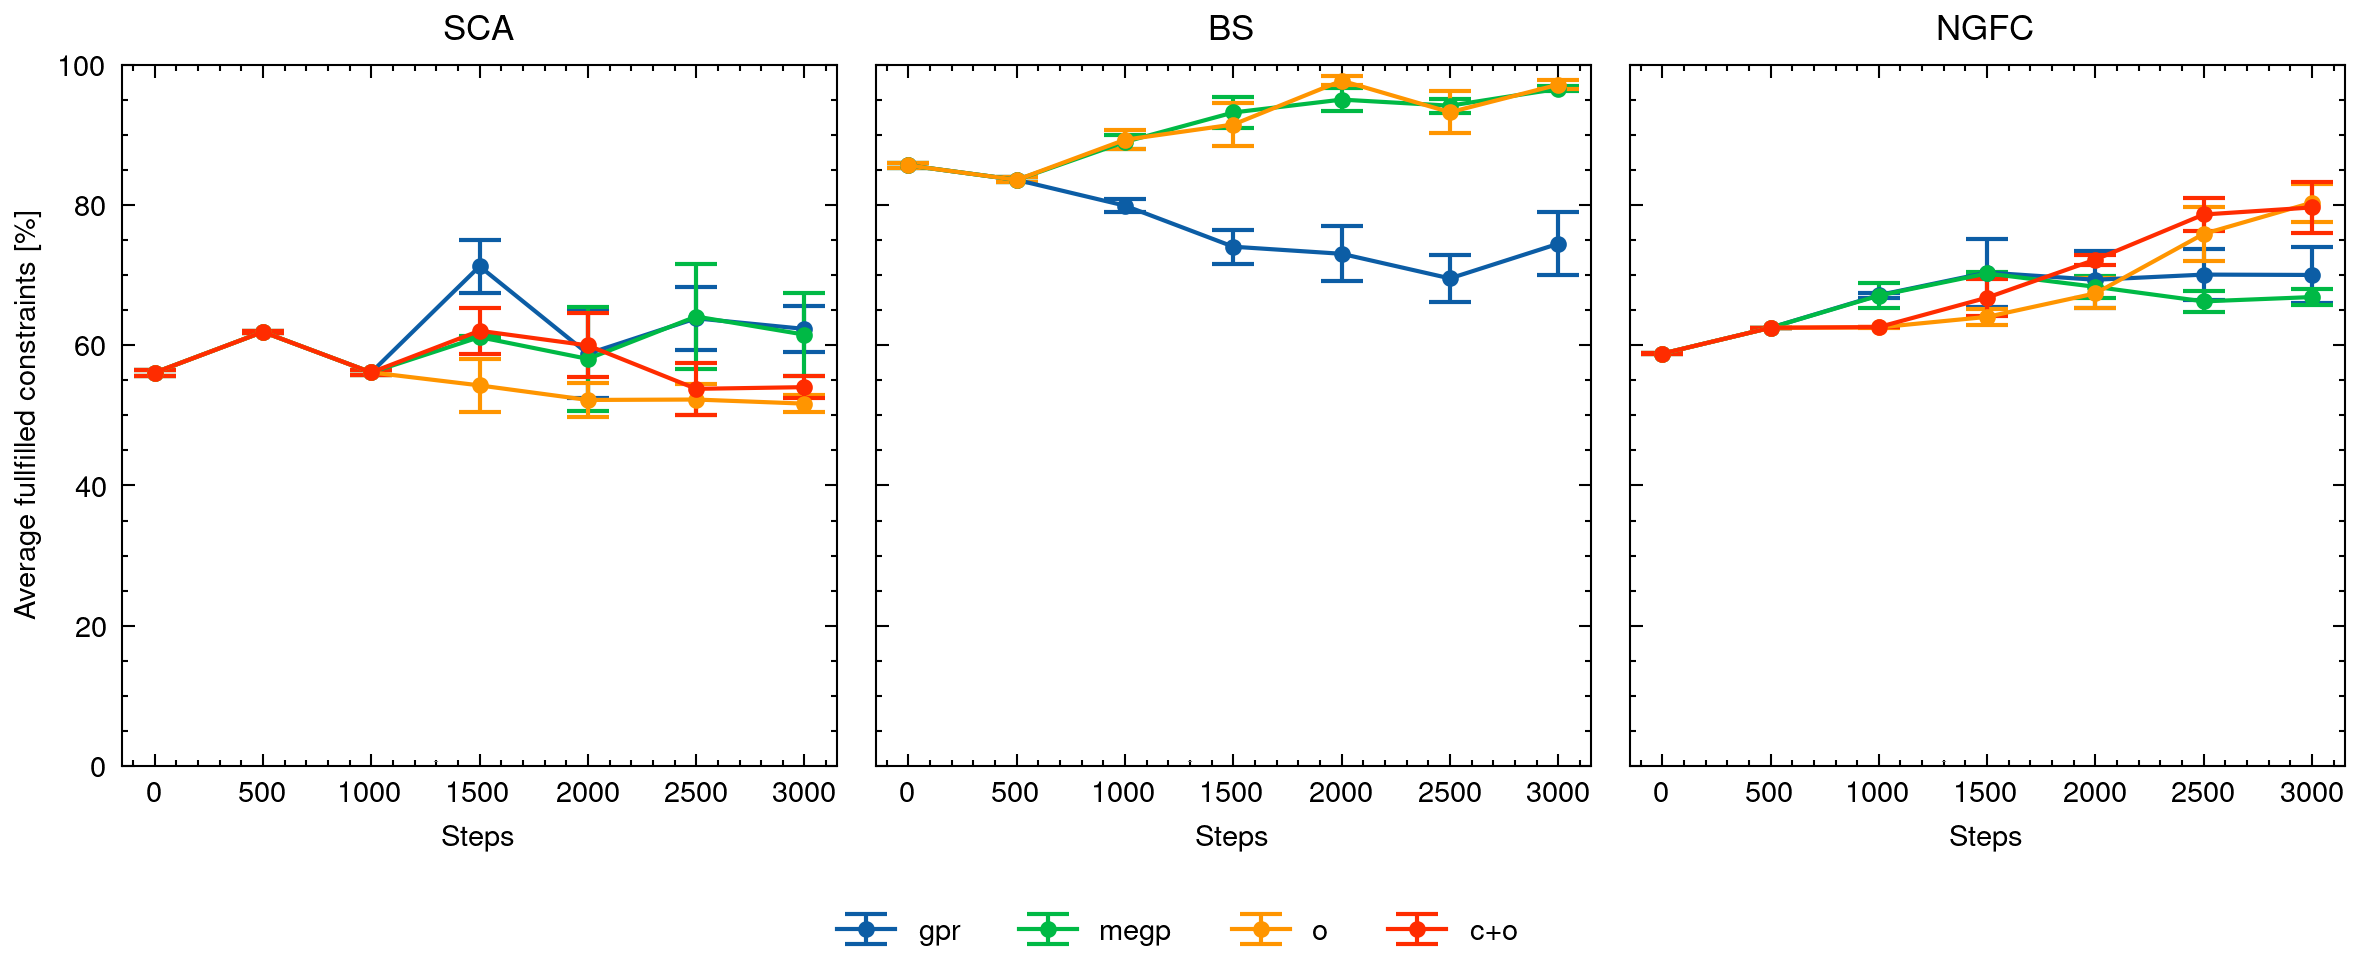

In [ ]:
fig, axs = plt.subplots(1, len(constraints["data"]), figsize=(8, 3), sharey=True)

for ax, (cell_type, models) in zip(axs.flatten(), constraints["data"].items()):
    for model_name, ccs in models.items():
        try:
            ccs = np.array(ccs) * 100
        except:
            continue
        x = range(0, constraints["num_"], constraints["chunk_size"])
        y = ccs.mean(axis=0)
        y_err = ccs.std(axis=0) / np.sqrt(len(ccs))
        ax.errorbar(x, y, yerr=y_err, label=model_name, fmt="-o", capsize=5)

    ax.set_xlabel("Steps")
    ax.vlines(
        constraints["n_initial"],
        np.min(reduce),
        np.max(reduce),
        color="grey",
        linestyle="--",
    )
    ax.set_ylim(0, 100)
    ax.set_title(cell_type)

axs[0].set_ylabel("Average fullfilled constraints [\\%]")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

In [ ]:
stash("single-cells-constraints", fig)

## Surrogate accuracy

In [ ]:
surrogate_accuracy = {"data": {}}

for p in populations:
    experiments = sopts.filter(lambda x: p in x.label())

    yy = []
    for experiment in experiments:
        h5 = experiment.load_h5()
        yy.append(h5["predictions"].to_numpy()[experiment.num_initial_samples :])
        yy.append(h5["objectives"].to_numpy()[experiment.num_initial_samples :])
    yy = np.vstack(yy)
    yy = yy[~np.isnan(yy)]
    yy_mean = np.mean(yy, axis=0)
    yy_std = np.std(yy, axis=0)

    def norm(y):
        return (y - yy_mean) / (yy_std + 1e-9)

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        sampler_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        surrogate_accuracy["n_initial"] = n_initial = experiment.num_initial_samples
        surrogate_accuracy["data"].setdefault(cell_type, {})
        surrogate_accuracy["data"][cell_type].setdefault(sampler_name, {})

        h5 = experiment.load_h5()
        y_pred = norm(h5["predictions"].to_numpy()[n_initial:])
        y = norm(h5["objectives"].to_numpy()[n_initial:])

        nmae = np.abs(y - y_pred)

        N = int(experiment.num_evals_per_epoch * (experiment.num_evals_per_epoch - 1))
        nmae = np.pad(nmae, ((0, N - nmae.shape[0]), (0, 0)), constant_values=np.nan)

        # average in chunks of a 100
        surrogate_accuracy["chunk_size"] = chunk_size = 100
        start = 0  # experiment.num_initial_samples
        surrogate_accuracy["num"] = num = len(nmae) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        surrogate_accuracy["num_"] = end
        d = surrogate_accuracy["data"][cell_type][sampler_name]
        for i, col in enumerate(h5["objectives"].columns):
            d.setdefault(col, [])
            reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)
            d[col].append(reduce)

/tmp/ipykernel_1869844/1500208159.py:49: RuntimeWarning: Mean of empty slice
  reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)


In [ ]:
stash("single-cells-surrogate-accuracy.p", surrogate_accuracy)

In [ ]:
surrogate_accuracy = restore("single-cells-surrogate-accuracy.p")

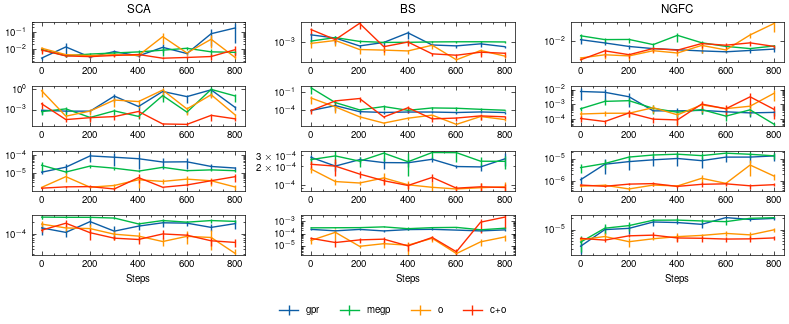

In [ ]:
fig, axs = plt.subplots(
    4, len(surrogate_accuracy["data"]), figsize=(8, 3), sharey=False
)

for ax, (cell_type, models) in zip(axs.T, surrogate_accuracy["data"].items()):
    for sampler_name, metric in models.items():
        c = 0
        for field, mm in metric.items():
            mm = np.array(mm)
            x = np.arange(
                0, surrogate_accuracy["num_"], surrogate_accuracy["chunk_size"]
            )
            y = mm.mean(axis=0)
            y_err = mm.std(axis=0) / np.sqrt(len(mm))

            ax[c].errorbar(x, y, yerr=y_err, label=sampler_name)
            ax[c].set_yscale("log")
            c += 1

    ax[-1].set_xlabel("Steps")
    # ax.set_ylim(0, 100)
    ax[0].set_title(cell_type)

# axs[0].set_ylabel('Normalized Mean Absolute Error')

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("single-cells-surrogate-accuracy", fig)